In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [308]:
# Membaca file CSV
df = pd.read_csv('heart (2).csv')

# Menampilkan 5 baris pertama dari data
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [309]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Onehot encoding

In [310]:
kolom_kategori = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_onehot = pd.get_dummies(df, columns=kolom_kategori, dtype=int)

print(df_onehot.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0      0      1                  0  ...                  0                 0   
1      1      0                  0  ...                  1                 0   
2      0      1                  0  ...                  0                 0   
3      1      0                  1  ...                  0                 0   
4      0      1                  0  ...                  1                 0   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  ExerciseAngina_

deteksi outlier

In [311]:
kolomuntukdeteksioutlier = [col for col in df_onehot.select_dtypes(include=[np.number]).columns if df_onehot[col].nunique()>2]
print(kolomuntukdeteksioutlier )

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


<Axes: xlabel='HeartDisease', ylabel='count'>

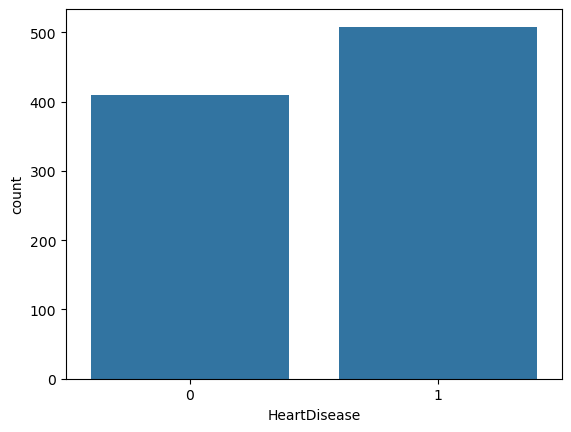

In [312]:
sns.countplot(x='HeartDisease', data=df)

<Axes: >

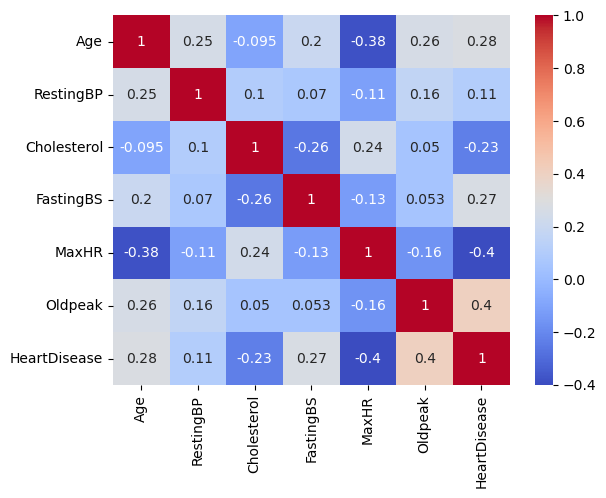

In [313]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')

In [314]:
for col in kolomuntukdeteksioutlier:
    Q1 = df_onehot[col].quantile(0.25)
    Q3 = df_onehot[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    #membuatdf baru untuk khusus tanpa data outlier yang bawah
    # if col  == "RestingBP" or col == "Cholesterol":
    #     dfbaru = df[df_onehot(["RestingBP"] >= lower_bound) | (df_onehot["Cholesterol"])]
    outliers = df_onehot[(df_onehot[col] < lower_bound) | (df_onehot[col] > upper_bound)]
    
    if len(outliers) > 0:
        print(f"Kolom {col}: Ditemukan {len(outliers)} outlier")
    else:
        print(f"Kolom {col}: Aman (0 outlier)")

Kolom Age: Aman (0 outlier)
Kolom RestingBP: Ditemukan 28 outlier
Kolom Cholesterol: Ditemukan 183 outlier
Kolom MaxHR: Ditemukan 2 outlier
Kolom Oldpeak: Ditemukan 16 outlier


<Axes: xlabel='Cholesterol'>

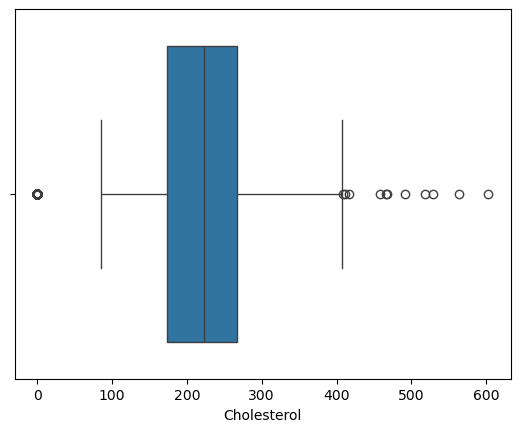

In [315]:
sns.boxplot(x=df_onehot["Cholesterol"])

MEnghapus bagian outlier bawah kolesterol dan resting bp

In [316]:
dfbaru = df_onehot.copy()
Q1_bp = df_onehot['RestingBP'].quantile(0.25)
Q3_bp = df_onehot['RestingBP'].quantile(0.75)
IQR_bp = Q3_bp - Q1_bp
lower_bound_bp = Q1_bp - 1.5 * IQR_bp

Q1_chol = df_onehot['Cholesterol'].quantile(0.25)
Q3_chol = df_onehot['Cholesterol'].quantile(0.75)
IQR_chol = Q3_chol - Q1_chol
lower_bound_chol = Q1_chol - 1.5 * IQR_chol

dfbaru.loc[dfbaru['RestingBP'] < lower_bound_bp, 'RestingBP'] = lower_bound_bp

dfbaru.loc[dfbaru['Cholesterol'] < lower_bound_chol, 'Cholesterol'] = lower_bound_chol
print(dfbaru)


     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0     40        140        289.0          0    172      0.0             0   
1     49        160        180.0          0    156      1.0             1   
2     37        130        283.0          0     98      0.0             0   
3     48        138        214.0          0    108      1.5             1   
4     54        150        195.0          0    122      0.0             0   
..   ...        ...          ...        ...    ...      ...           ...   
913   45        110        264.0          0    132      1.2             1   
914   68        144        193.0          1    141      3.4             1   
915   57        130        131.0          0    115      1.2             1   
916   57        130        236.0          0    174      0.0             1   
917   38        138        175.0          0    173      0.0             0   

     Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  \
0        0 

In [317]:
dfzscor = dfbaru.copy()
del(kolomuntukdeteksioutlier[4])
dfzscor['Oldpeak'] = dfzscor['Oldpeak'] + 3.0  
dfzscor['Oldpeak'] = np.log1p(dfzscor['Oldpeak'])
dfzscor[kolomuntukdeteksioutlier] = dfzscor[kolomuntukdeteksioutlier].apply(zscore)
print(dfzscor)


          Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak  \
0   -1.433140   0.416223     0.854508          0  1.382928  1.386294   
1   -0.478484   1.526958    -0.253162          0  0.754157  1.609438   
2   -1.751359  -0.139144     0.793536          0 -1.525138  1.386294   
3   -0.584556   0.305150     0.092350          0 -1.132156  1.704748   
4    0.051881   0.971591    -0.100730          0 -0.581981  1.386294   
..        ...        ...          ...        ...       ...       ...   
913 -0.902775  -1.249879     0.600456          0 -0.188999  1.648659   
914  1.536902   0.638370    -0.121054          1  0.164684  2.001480   
915  0.370100  -0.139144    -0.751105          0 -0.857069  1.648659   
916  0.370100  -0.139144     0.315917          0  1.461525  1.386294   
917 -1.645286   0.305150    -0.303972          0  1.422226  1.386294   

     HeartDisease  Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  \
0               0      0      1                  0  ...  

In [318]:
dfzscor['HeartDisease'] =dfzscor['HeartDisease'].replace({0: 'N', 1: 'Y'})

In [319]:
X = dfzscor.drop('HeartDisease', axis=1)

y = dfzscor['HeartDisease']

# 1. Split data (Asumsi X adalah fitur dan y adalah target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Banyak data latih: {len(X_train)} pasien")
print(f"Banyak data uji: {len(X_test)} pasien")

Banyak data latih: 642 pasien
Banyak data uji: 276 pasien


In [320]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [321]:
hasilakurasi =[]
for i in range(1,100):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    hasilakurasi.append(accuracy_score(y_test, y_pred))

print(f"Akurasi tertinggi: {max(hasilakurasi)} Dengan menggunakan N = {hasilakurasi.index(max(hasilakurasi)) + 1}")

Akurasi tertinggi: 0.8913043478260869 Dengan menggunakan N = 19


In [323]:
from sklearn.model_selection import GridSearchCV
range_setelan = {'n_neighbors': list(range(1, 100)), 'weights': ['uniform', 'distance'],  # Mode perhitungan jarak biasa atau berdasarkan kedekatan
'p': [1, 2, 8.5]}                         # Rumus jarak garis lurus (Manhattan) atau melingkar (Euclidean)
# 2. Panggil asisten pencari otomatis kita
X_train_scaled = scaler.fit_transform(X_train)
knn_baru = KNeighborsClassifier()
asisten_grid = GridSearchCV(knn_baru, range_setelan, cv=5, scoring='accuracy')
# 3. Suruh Asisten mencoba semua kombinasi ratusan uji coba itu
print("Sedang mencari setelan terbaik... Mohon tunggu!")
asisten_grid.fit(X_train_scaled, y_train)
# 4. Lihat Hasil Rahasianya!
print("Setelan Paling Sempurna (Hyperparameter Terbaik):")
print(asisten_grid.best_params_)
print(f"Akurasi Terbaik di Data Latih: {asisten_grid.best_score_ * 100:.2f}%")
# (Setelah ini, Anda tinggal memasukkan hasil ujian dari Asisten ini untuk uji tes akhir)

Sedang mencari setelan terbaik... Mohon tunggu!
Setelan Paling Sempurna (Hyperparameter Terbaik):
{'n_neighbors': 20, 'p': 1, 'weights': 'distance'}
Akurasi Terbaik di Data Latih: 86.44%
